<a href="https://colab.research.google.com/github/MuBasHarAkBar/house-price-prediction-from-scratch/blob/main/House_Pricing_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("modified_data.csv")

print(df.shape)



(4600, 18)


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

In [5]:
df.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [6]:
df.isnull().sum()


,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [7]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [8]:
df[df["price"] == 0]
(df["price"] == 0) . sum()


np.int64(49)

In [9]:
df.nlargest(10, "price")[["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot"]]


,price,bedrooms,bathrooms,sqft_living,sqft_lot
4350,26590000.0,3.0,2.00,1180,7793
4346,12899000.0,3.0,2.50,2190,11394
2286,7062500.0,5.0,4.50,10040,37325
2654,4668000.0,5.0,6.75,9640,13068
2761,4489000.0,4.0,3.00,6430,27517
3729,3800000.0,5.0,5.50,7050,42840
1637,3710000.0,4.0,3.50,5550,28078
252,3200000.0,7.0,4.50,6210,8856
1567,3100000.0,6.0,4.25,6980,15682
2772,3000000.0,4.0,4.25,4850,12445


In [10]:
df.nlargest(10, "price_per_sqft")[["price", "sqft_living", "price_per_sqft"]]

,price,sqft_living,price_per_sqft
4350,26590000.00,1180,22533.90
4346,12899000.00,2190,5889.95
4348,2199900.00,1120,1964.20
4465,2560498.33,1710,1497.37
4347,2110000.00,2100,1004.76
404,2400000.00,3000,800.00
478,1200000.00,1560,769.23
3778,276000.00,370,745.95
3923,1755000.00,2360,743.64
1186,1180500.00,1610,733.23


In [11]:
df[df["price"] == 0][
    ["price", "bedrooms", "bathrooms", "sqft_living",
     "sqft_lot", "floors", "yr_built"]
].head(20)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,yr_built
4354,0.0,3.0,1.75,1490,10125,1.0,1962
4356,0.0,4.0,2.75,2600,5390,1.0,1960
4357,0.0,6.0,2.75,3200,9200,1.0,1953
4358,0.0,5.0,3.50,3480,36615,2.0,1983
4361,0.0,5.0,1.50,1500,7112,1.0,1920
4362,0.0,4.0,4.00,3680,18804,2.0,1990
4374,0.0,2.0,2.50,2200,188200,1.0,2007
4376,0.0,4.0,2.25,2170,10500,1.0,1960
4382,0.0,5.0,4.50,4630,6324,2.0,2006
4383,0.0,5.0,4.00,4430,9000,2.0,2013


In [12]:
df[df["price"] == 0].describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,49.0,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.0
mean,0.0,3.979592,2.698980,2787.142857,16453.306122,1.500000,0.061224,0.795918,3.673469,2295.714286,491.428571,1969.918367,812.714286,0.0
std,0.0,1.108486,1.194584,1354.375625,27739.227932,0.520416,0.242226,1.485760,0.826331,1337.148708,612.726149,27.247964,988.903054,0.0
min,0.0,1.000000,1.000000,720.000000,3500.000000,1.000000,0.000000,0.000000,2.000000,720.000000,0.000000,1920.000000,0.000000,0.0
25%,0.0,3.000000,2.000000,1910.000000,6863.000000,1.000000,0.000000,0.000000,3.000000,1310.000000,0.000000,1952.000000,0.000000,0.0
50%,0.0,4.000000,2.500000,2600.000000,9000.000000,1.500000,0.000000,0.000000,3.000000,1990.000000,0.000000,1962.000000,0.000000,0.0
75%,0.0,5.000000,3.500000,3500.000000,13783.000000,2.000000,0.000000,0.000000,4.000000,3020.000000,900.000000,1998.000000,1999.000000,0.0
max,0.0,6.000000,6.250000,8020.000000,188200.000000,3.000000,1.000000,4.000000,5.000000,8020.000000,1950.000000,2013.000000,2009.000000,0.0


In [4]:
df = df[df["price"] > 0].copy()

In [5]:
print(df.shape)
print((df["price"] == 0).sum())

(4551, 18)
0


In [7]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated"
]
X = df[features].values
y = df["price"].values

In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4551, 12)
y shape: (4551,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3640, 12)
X_test: (911, 12)
y_train: (3640,)
y_test: (911,)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Before scaling:")
print(X_train[:5])

print("\nAfter scaling:")
print(X_train_scaled[:5])
print("Mean:", X_train_scaled.mean(axis=0))
print("Std:", X_train_scaled.std(axis=0))

Before scaling:
[[4.0000e+00 1.7500e+00 1.3600e+03 4.8400e+03 1.5000e+00 0.0000e+00
  0.0000e+00 4.0000e+00 1.3600e+03 0.0000e+00 1.9280e+03 0.0000e+00]
 [3.0000e+00 2.2500e+00 2.2100e+03 8.0000e+03 2.0000e+00 0.0000e+00
  0.0000e+00 4.0000e+00 2.2100e+03 0.0000e+00 1.9690e+03 0.0000e+00]
 [3.0000e+00 1.0000e+00 1.2000e+03 8.5140e+03 1.0000e+00 0.0000e+00
  0.0000e+00 3.0000e+00 1.2000e+03 0.0000e+00 1.9590e+03 1.9890e+03]
 [3.0000e+00 2.5000e+00 2.8600e+03 4.3821e+04 2.0000e+00 0.0000e+00
  0.0000e+00 4.0000e+00 2.8600e+03 0.0000e+00 1.9900e+03 0.0000e+00]
 [3.0000e+00 1.7500e+00 1.7600e+03 1.0780e+04 1.0000e+00 0.0000e+00
  0.0000e+00 3.0000e+00 1.7600e+03 0.0000e+00 1.9770e+03 2.0040e+03]]

After scaling:
[[ 0.68289676 -0.51996945 -0.81710783 -0.26917841 -0.02181984 -0.07617551
  -0.30374451  0.8032276  -0.53751223 -0.68450135 -1.41171843 -0.81735505]
 [-0.42138765  0.13313227  0.09297492 -0.1830638   0.91258259 -0.07617551
  -0.30374451  0.8032276   0.46867096 -0.68450135 -0.044833

In [13]:
import numpy as np

w = np.zeros(X_train_scaled.shape[1])
b = 0

print("w shape:", w.shape)
print("b:", b)

w shape: (12,)
b: 0


In [14]:
def predict(X, w, b):
    prediction = X @ w + b
    return prediction

def compute_cost(X, y, w, b):
    prediction = X @ w + b
    error = prediction - y

    cost = np.mean(error ** 2)

    return cost

def compute_gradient(X, y, w, b):
    prediction = X @ w + b
    error = prediction - y

    m = len(y)

    gradient_w = (2 / m) * (X.T @ error)
    gradient_b = (2 / m) * np.sum(error)

    return gradient_w, gradient_b


def gradient_descent(X, y, w, b, alpha, iterations):

    cost_history = []

    for i in range(iterations):

        # Calculate gradients
        gradient_w, gradient_b = compute_gradient(X, y, w, b)

        # Update weights
        w = w - alpha * gradient_w

        # Update bias
        b = b - alpha * gradient_b

        # Calculate and store cost
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

    return w, b, cost_history

In [21]:
alphas = [0.001, 0.003, 0.01, 0.03, 0.1]

results = []

for alpha in alphas:

    # Start from the same initial values every time
    w = np.zeros(X_train_scaled.shape[1])
    b = 0

    w_final, b_final, cost_history = gradient_descent(
        X_train_scaled,
        y_train,
        w,
        b,
        alpha,
        2000
    )

    # Test predictions
    y_pred = predict(X_test_scaled, w_final, b_final)

    # Metrics
    mae = np.mean(np.abs(y_test - y_pred))
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    results.append((alpha, cost_history[-1], mae, rmse, r2))

for result in results:
    print(
        f"alpha={result[0]:.3f} | "
        f"cost={result[1]:,.0f} | "
        f"MAE=${result[2]:,.0f} | "
        f"RMSE=${result[3]:,.0f} | "
        f"R²={result[4]:.4f}"
    )

alpha=0.001 | cost=289,112,126,617 | MAE=$159,655 | RMSE=$243,564 | R²=0.6012
alpha=0.003 | cost=288,718,618,460 | MAE=$160,666 | RMSE=$243,733 | R²=0.6007
alpha=0.010 | cost=288,718,084,152 | MAE=$160,682 | RMSE=$243,748 | R²=0.6006
alpha=0.030 | cost=288,718,084,152 | MAE=$160,682 | RMSE=$243,748 | R²=0.6006
alpha=0.100 | cost=288,718,084,152 | MAE=$160,682 | RMSE=$243,748 | R²=0.6006


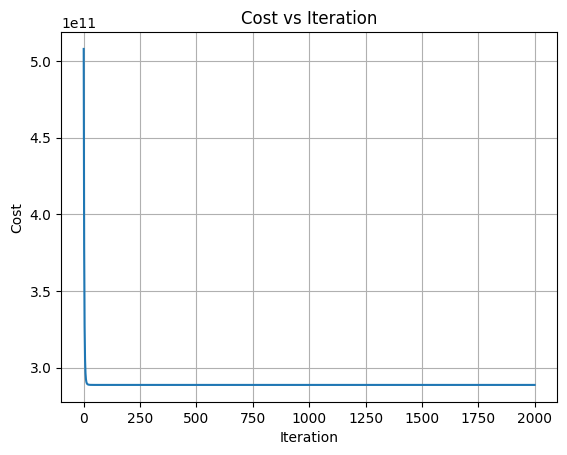

In [22]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.grid(True)
plt.show()

In [24]:


y_pred = predict(X_test_scaled, w_final, b_final)

print("First 10 actual prices:")
print(y_test[:10])

print("\nFirst 10 predicted prices:")
print(y_pred[:10])




First 10 actual prices:
[1225000.  496752.  612500.  265000.  615000.  432000.  305000.  405000.
  349000.  839000.]

First 10 predicted prices:
[1339847.18215925  599271.66118242  654774.55128501  276870.28812069
  512959.85671455  524862.11155399  232634.83754268  186991.65716321
  367374.07808411  671939.99615456]


In [25]:

# STEP 9: Calculate MAE


mae = np.mean(np.abs(y_test - y_pred))

print("\nMAE:", mae)


# STEP 10: Calculate RMSE


rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print("RMSE:", rmse)



# STEP 11: Calculate R²


ss_res = np.sum((y_test - y_pred) ** 2)

ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("R²:", r2)






MAE: 160681.99953337866
RMSE: 243747.93884227885
R²: 0.6006392305720758


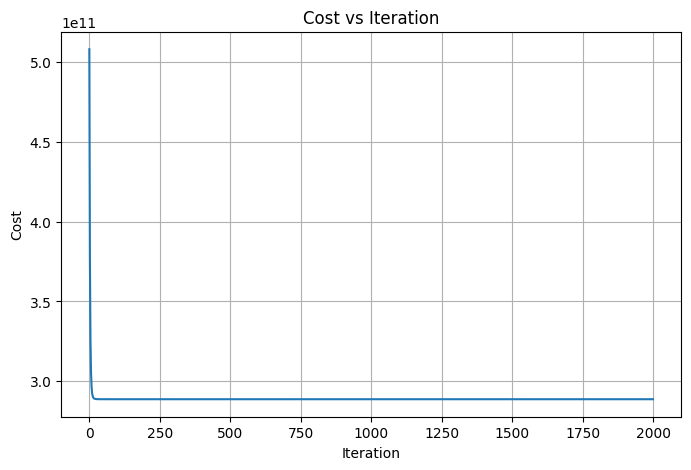

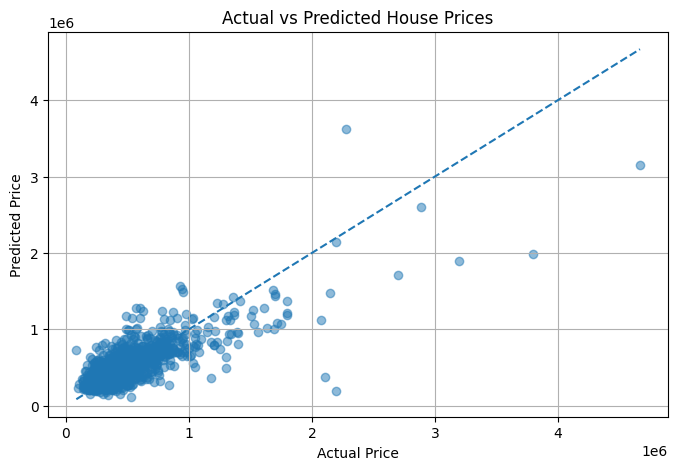


========== FINAL MODEL RESULTS ==========
Number of features: 12
Training examples: 3640
Test examples: 911

Final Cost: 288718084151.67017
MAE: 160681.99953337866
RMSE: 243747.93884227885
R²: 0.6006392305720758


In [26]:

# STEP 12: Plot Cost vs Iteration


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.grid(True)

plt.show()


# STEP 13: Plot Actual vs Predicted Prices


plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)

plt.show()



# STEP 14: Print final model information


print("\n========== FINAL MODEL RESULTS ==========")

print("Number of features:", X_train_scaled.shape[1])
print("Training examples:", X_train_scaled.shape[0])
print("Test examples:", X_test_scaled.shape[0])

print("\nFinal Cost:", cost_history[-1])
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)